In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries/ai_jobs_market_2025_2026.csv


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

## Load Dataset

In [21]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv("/kaggle/input/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries/ai_jobs_market_2025_2026.csv")

print("\nDataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nSalary Statistics")
print(df["annual_salary_usd"].describe())

/kaggle/input/datasets/alitaqishah/ai-jobs-market-2025-2026-salaries/ai_jobs_market_2025_2026.csv

Dataset Shape: (1500, 25)

Columns: ['job_id', 'job_title', 'job_category', 'experience_level', 'years_of_experience', 'education_required', 'annual_salary_usd', 'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work', 'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly', 'is_llm_role', 'salary_tier']

Salary Statistics
count      1500.000000
mean     194892.000000
std       66506.822013
min       90000.000000
25%      144750.000000
50%      180000.000000
75%      236250.000000
max      384000.000000
Name: annual_salary_usd, dtype: float64


## Feature Engineering

We create new features to improve model performance:

- salary_range → difference between min and max salary

- salary_mid → midpoint salary estimate

- skill_count → number of required skills

- exp_bucket → experience grouped into categories

Feature engineering helps models capture better patterns.

In [22]:
df["salary_range"] = df["salary_max_usd"] - df["salary_min_usd"]

df["salary_mid"] = (df["salary_max_usd"] + df["salary_min_usd"]) / 2

df["skill_count"] = df["required_skills"].fillna("").apply(lambda x: len(x.split("|")))

df["exp_bucket"] = pd.cut(
    df["years_of_experience"],
    bins=[0,2,5,9,20],
    labels=["Entry","Mid","Senior","Lead"]
)

## Visualization

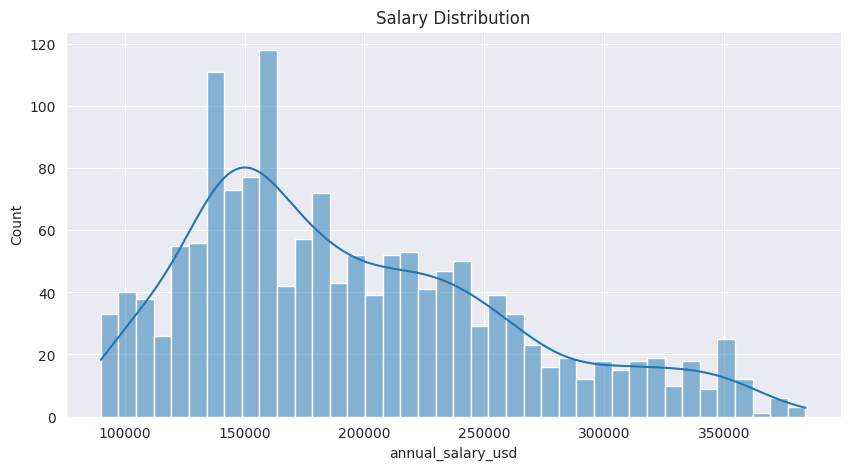

In [23]:
sns.set_style("darkgrid")

plt.figure(figsize=(10,5))
sns.histplot(df["annual_salary_usd"], bins=40, kde=True)
plt.title("Salary Distribution")
plt.show()

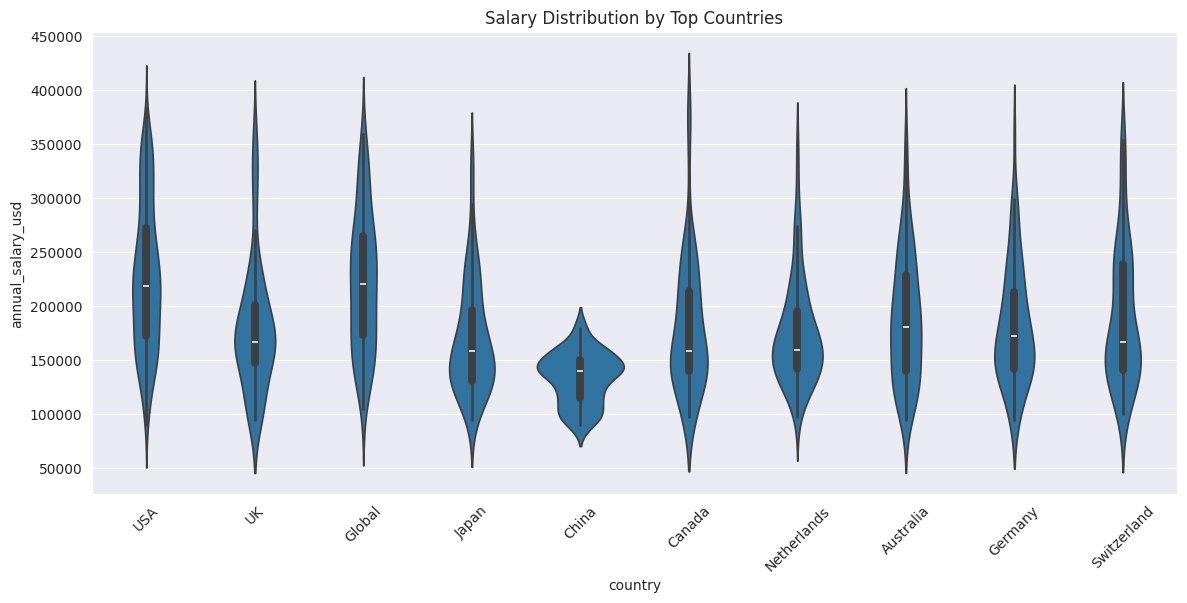

In [24]:
plt.figure(figsize=(14,6))

top_countries = df["country"].value_counts().head(10).index

sns.violinplot(
    data=df[df["country"].isin(top_countries)],
    x="country",
    y="annual_salary_usd"
)

plt.xticks(rotation=45)
plt.title("Salary Distribution by Top Countries")
plt.show()

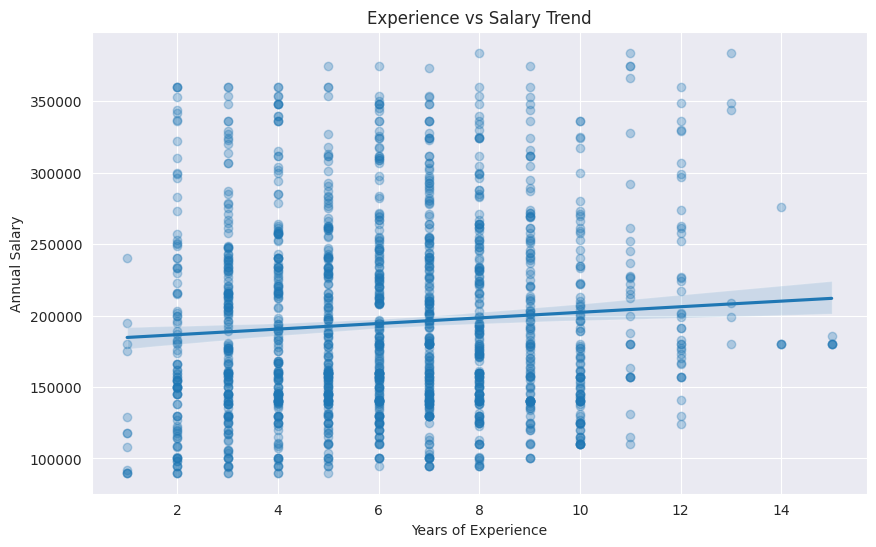

In [25]:
plt.figure(figsize=(10,6))

sns.regplot(
    x="years_of_experience",
    y="annual_salary_usd",
    data=df,
    scatter_kws={"alpha":0.3}
)

plt.title("Experience vs Salary Trend")
plt.xlabel("Years of Experience")
plt.ylabel("Annual Salary")
plt.show()

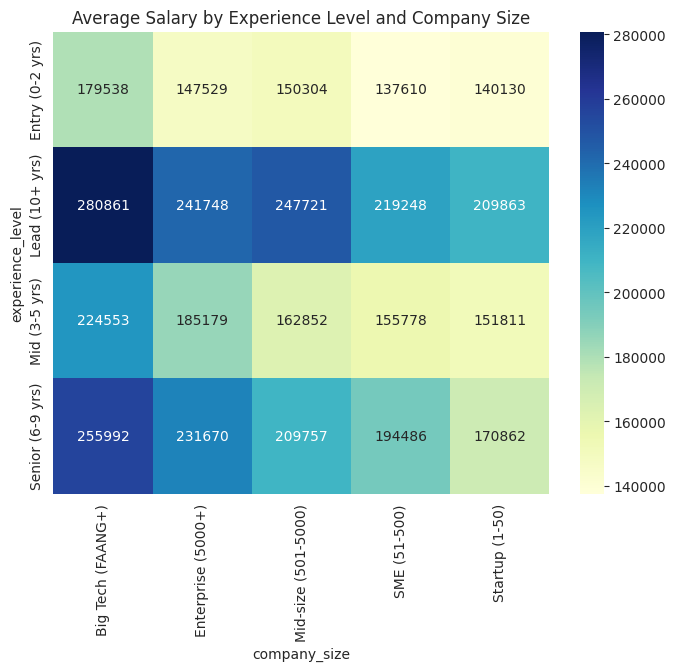

In [26]:
pivot = pd.pivot_table(
    df,
    values="annual_salary_usd",
    index="experience_level",
    columns="company_size",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title("Average Salary by Experience Level and Company Size")
plt.show()

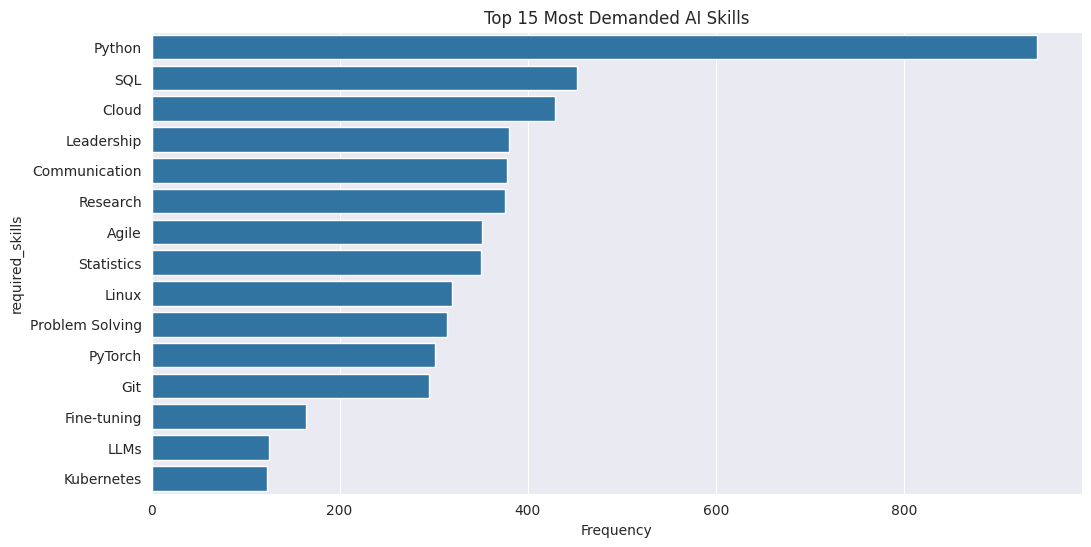

In [27]:
skills = (
    df["required_skills"]
    .dropna()
    .str.split("|")
    .explode()
)

top_skills = skills.value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.title("Top 15 Most Demanded AI Skills")
plt.xlabel("Frequency")
plt.show()

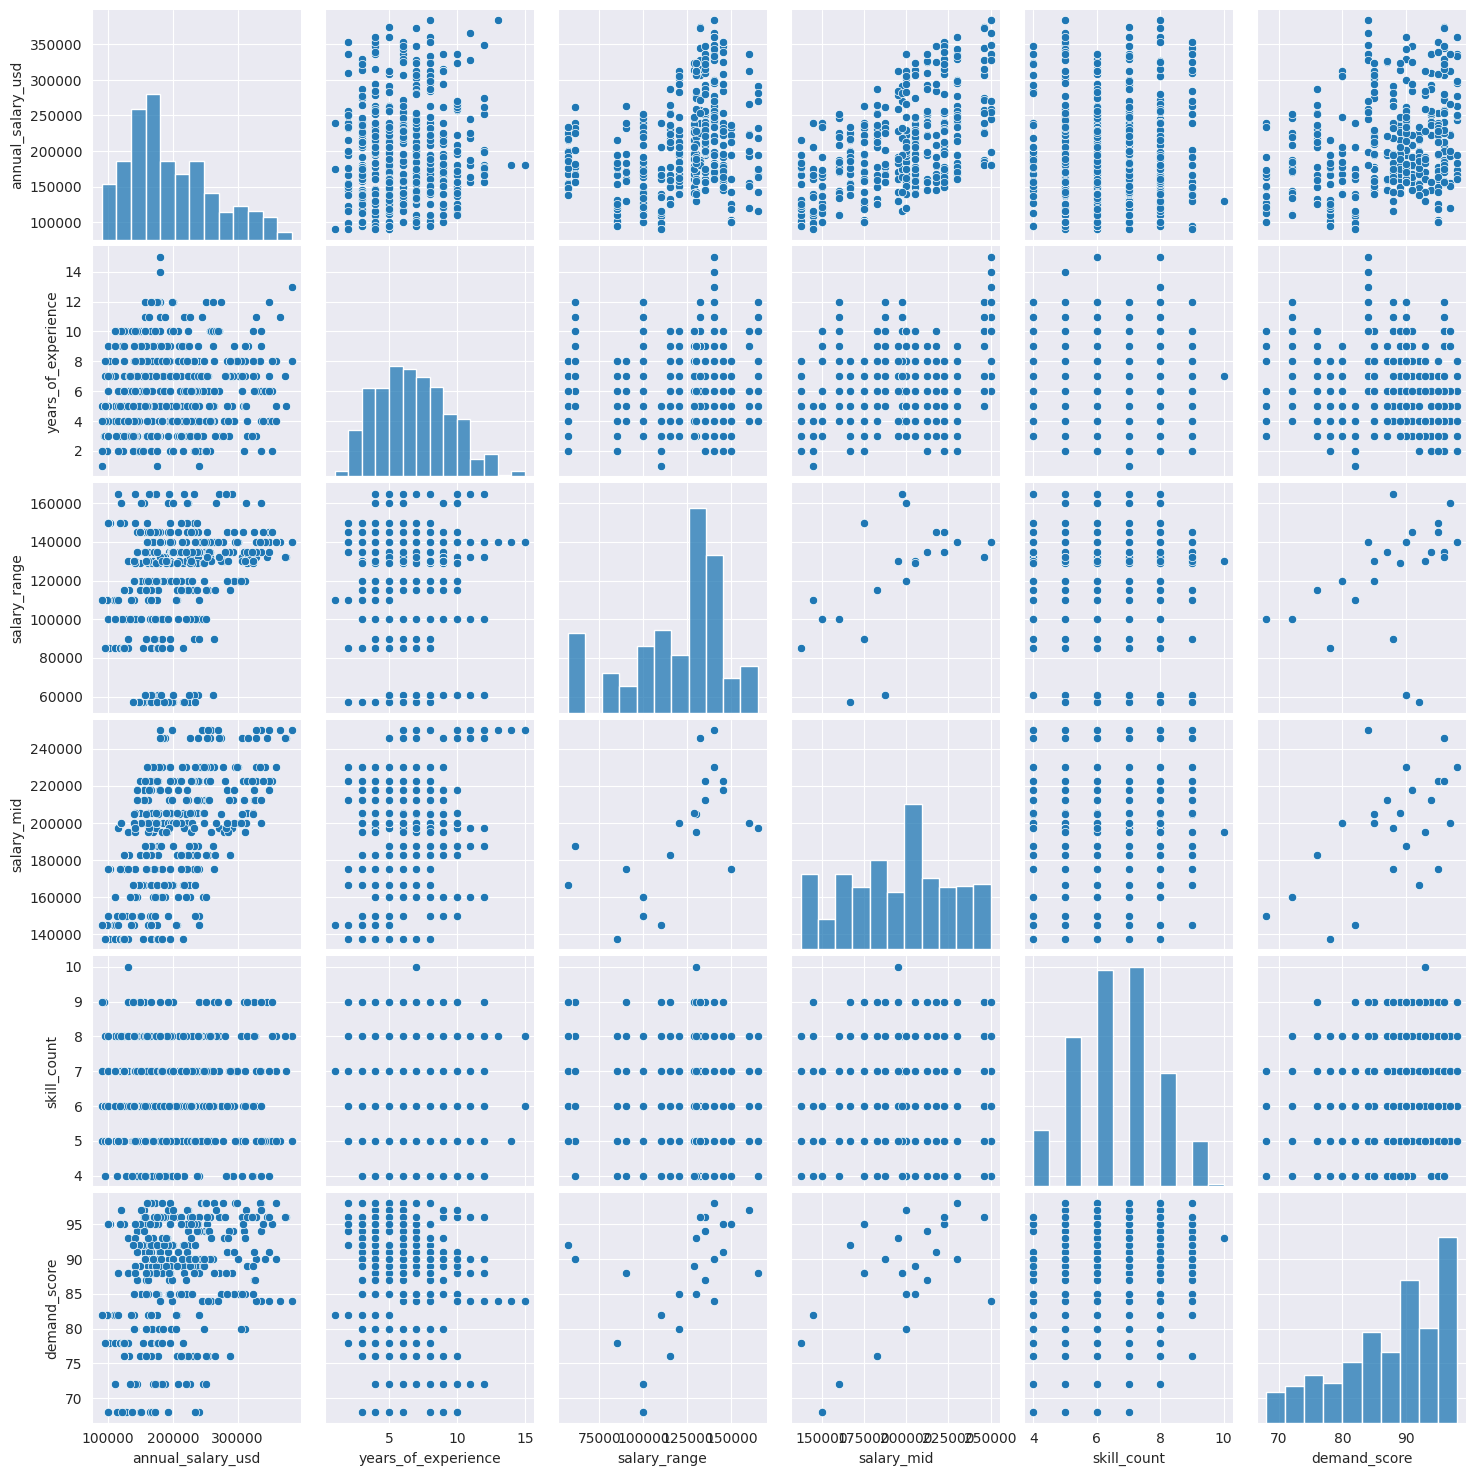

In [28]:
sample_df = df.sample(500)

sns.pairplot(
    sample_df[[
        "annual_salary_usd",
        "years_of_experience",
        "salary_range",
        "salary_mid",
        "skill_count",
        "demand_score"
    ]]
)

plt.show()

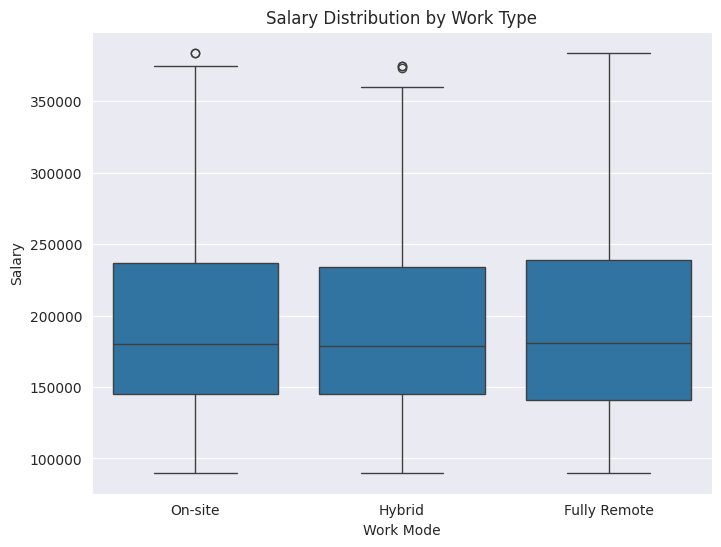

In [29]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="remote_work",
    y="annual_salary_usd",
    data=df
)

plt.title("Salary Distribution by Work Type")
plt.xlabel("Work Mode")
plt.ylabel("Salary")
plt.show()

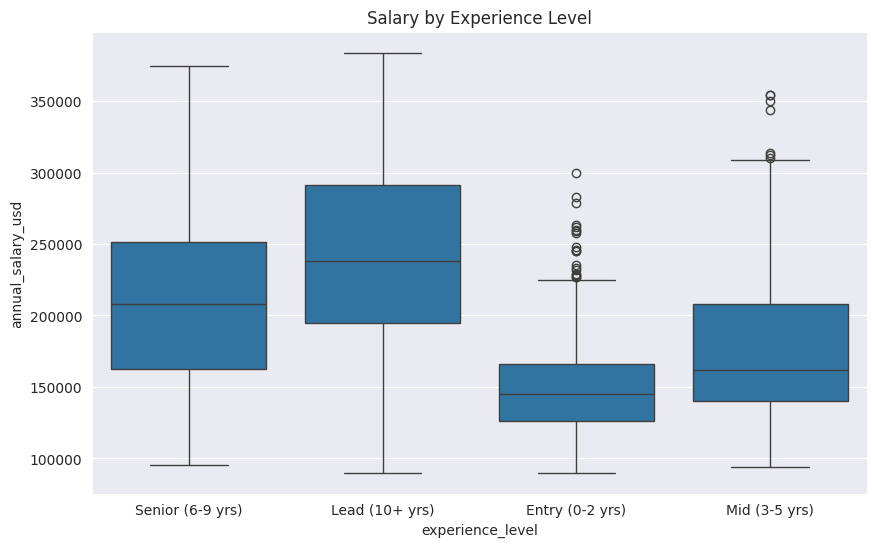

In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(x="experience_level", y="annual_salary_usd", data=df)
plt.title("Salary by Experience Level")
plt.show()

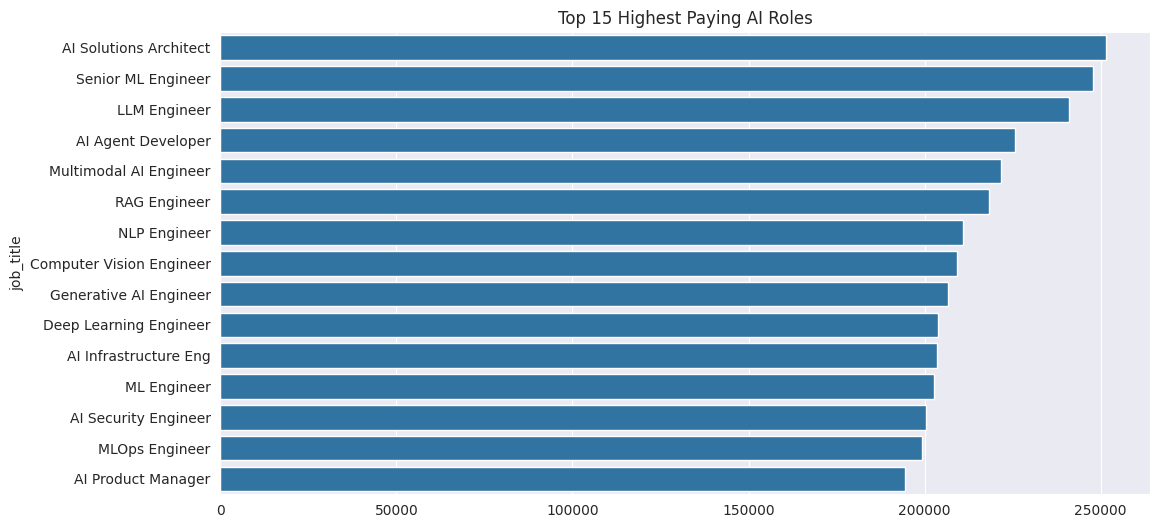

In [31]:
plt.figure(figsize=(12,6))
top_roles = df.groupby("job_title")["annual_salary_usd"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=top_roles.values, y=top_roles.index)
plt.title("Top 15 Highest Paying AI Roles")
plt.show()

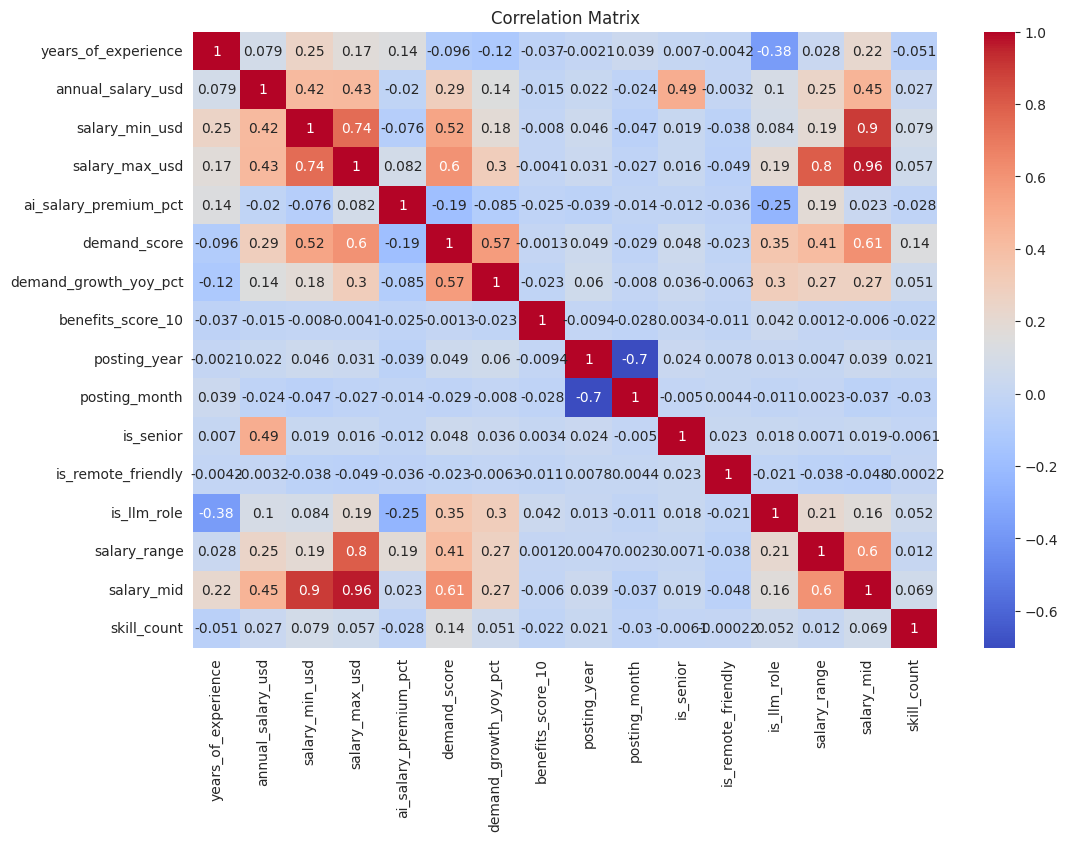

In [32]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Matrix")
plt.show()

## Data Preparation for Machine Learning

Steps performed:

- Select model features

- Encode categorical variables

- Split data into:

  - Training set (80%)

  - Testing set (20%)


In [33]:
features = [
    "job_title",
    "experience_level",
    "education_required",
    "country",
    "remote_work",
    "company_size",
    "industry",
    "years_of_experience",
    "salary_range",
    "salary_mid",
    "skill_count",
    "demand_score"
]

df_model = df[features + ["annual_salary_usd"]].copy()

le = LabelEncoder()

cat_cols = [
    "job_title",
    "experience_level",
    "education_required",
    "country",
    "remote_work",
    "company_size",
    "industry"
]

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model[features]
y = df_model["annual_salary_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Multiple ML Models

**We train four models:**

- Linear Regression

- Random Forest

- Gradient Boosting

- XGBoost

**Metrics used:**

- MAE (Mean Absolute Error)

- R² Score

- Cross Validation R²

In [34]:
models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    cv = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    ).mean()

    results.append([name, mae, r2, cv])

results_df = pd.DataFrame(
    results,
    columns=["Model","MAE","R2","CV_R2"]
)

print("\nMODEL LEADERBOARD")
print(results_df.sort_values("R2", ascending=False))


MODEL LEADERBOARD
               Model           MAE        R2     CV_R2
2  Gradient Boosting  18904.094380  0.847467  0.874013
3            XGBoost  18203.615990  0.847262  0.886703
1      Random Forest  24144.446667  0.711836  0.793522
0  Linear Regression  40762.429267  0.383892  0.473134


## Hyperparameter Tuning

In [35]:
param_grid = {
    "n_estimators":[200,300],
    "max_depth":[10,15,20]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("\nBest RF Parameters:", grid.best_params_)

best_rf = grid.best_estimator_


Best RF Parameters: {'max_depth': 20, 'n_estimators': 300}


## Actual vs Predicted Salary

Feature importance shows which factors most influence salary prediction.

Important predictors often include:

- Experience

- Job title

- Demand score

- Skill count

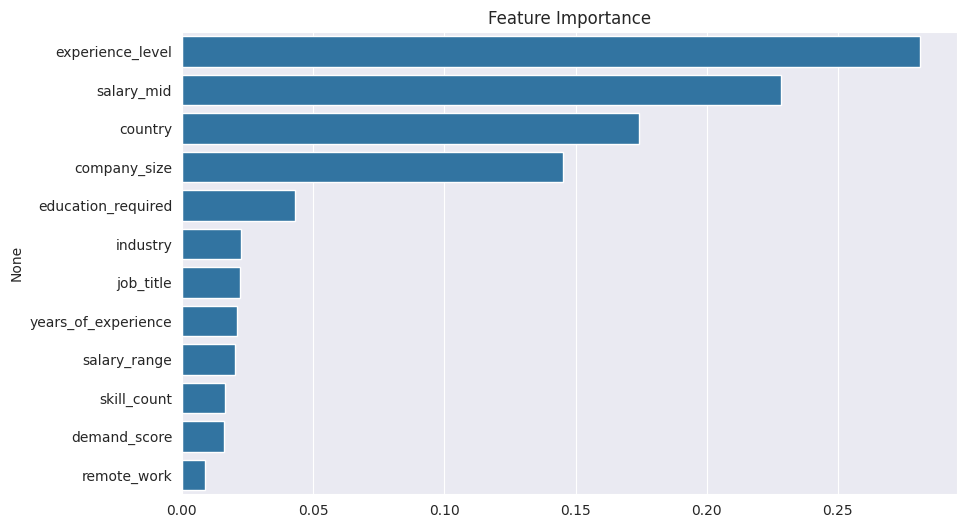

In [36]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=importances.values,
    y=importances.index
)

plt.title("Feature Importance")
plt.show()

## Actual vs Predicted Salary

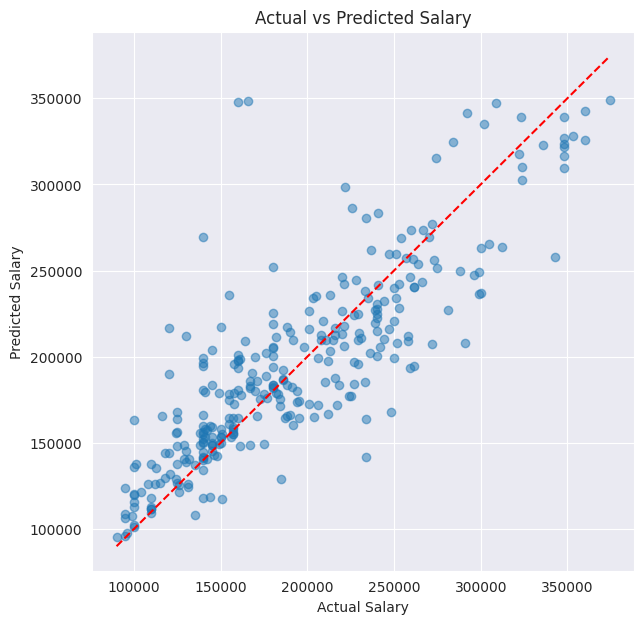

In [37]:
pred = best_rf.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.show()

## Final Insights

Final insights summarize the dataset:

- Total AI jobs analyzed

- Average salary

- Highest paying role

- Country with highest salaries

- Remote job percentage

-Best performing ML model

In [38]:
print("Total jobs:", len(df))

print("Average salary: $", int(df["annual_salary_usd"].mean()))

print(
"Highest paying role:",
df.groupby("job_title")["annual_salary_usd"].mean().idxmax()
)

print(
"Top country salary:",
df.groupby("country")["annual_salary_usd"].mean().idxmax()
)

print(
"Remote jobs percentage:",
round((df["remote_work"]!="On-site").mean()*100,1),
"%"
)

print("Best Model R2:", results_df["R2"].max())

Total jobs: 1500
Average salary: $ 194892
Highest paying role: AI Solutions Architect
Top country salary: USA
Remote jobs percentage: 75.4 %
Best Model R2: 0.847466783681759
